<a href="https://colab.research.google.com/github/riyap1404/Day1_Lab_RecordManager_starter/blob/main/Day3_Lab_business_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION (saas_churn_data.csv)
# Run this cell first to generate the portfolio-grade dataset on disk.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization standards
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

np.random.seed(42)
N = 1200

# Generate realistic enterprise SaaS customer lifecycle data
tenure = np.random.exponential(scale=18, size=N).clip(1, 72).astype(int)
contract = np.random.choice(["Month-to-Month", "One-Year", "Two-Year"], size=N, p=[0.55, 0.25, 0.20])
support_tickets = np.random.poisson(lam=1.8, size=N) + (contract == "Month-to-Month") * np.random.poisson(lam=1.2, size=N)
monthly_charges = np.random.normal(loc=75.0, scale=25.0, size=N).clip(20.0, 150.0)
tech_support = np.random.choice(["Yes", "No", "No internet"], size=N, p=[0.40, 0.45, 0.15])
payment_method = np.random.choice(["Electronic Check", "Bank Transfer", "Credit Card"], size=N, p=[0.40, 0.30, 0.30])

# Complex churn probability generator
churn_logits = (
    - 2.0
    + 0.03 * monthly_charges
    - 0.05 * tenure
    + 0.45 * support_tickets
    + 1.2 * (contract == "Month-to-Month")
    - 1.0 * (contract == "Two-Year")
    + 0.8 * (payment_method == "Electronic Check")
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn = np.where(np.random.rand(N) < churn_prob, "Yes", "No")

# Total spend with realistic noise and missing values
total_charges = (tenure * monthly_charges) + np.random.normal(0, 50, size=N)
total_charges[np.random.choice(N, size=15, replace=False)] = np.nan

eda_df = pd.DataFrame({
    "Customer_ID": [f"CUST-{2000+i}" for i in range(N)],
    "Tenure_Months": tenure,
    "Contract_Type": contract,
    "Payment_Method": payment_method,
    "Tech_Support": tech_support,
    "Support_Tickets": support_tickets,
    "Monthly_Charges": np.round(monthly_charges, 2),
    "Total_Charges": np.round(total_charges, 2),
    "Churn": churn
})

eda_df.to_csv("saas_churn_data.csv", index=False)
print("Synthetic dataset 'saas_churn_data.csv' successfully created!")

✅ Synthetic dataset 'saas_churn_data.csv' successfully created!


In [2]:
# ==============================================================================
# STAGE 1: BUSINESS CONTEXT & PROBLEM FRAMING
# ==============================================================================
"""
BUSINESS CONTEXT:
CloudPulse is an enterprise B2B SaaS platform experiencing an unexpected rise in
customer churn over the last two quarters. Customer Acquisition Cost (CAC) is $450,
while Average Annual Contract Value (ACV) is $1,200.

ANALYTICAL OBJECTIVES:
1. Identify demographic, contractual, and behavioral profiles of at-risk customers.
2. Determine key inflection points (tenure, ticket volume, pricing tiers) where churn accelerates.
3. Formulate data-driven hypotheses for retention intervention by the Customer Success team.

STRUCTURED EDA WORKFLOW:
┌────────────────────┐     ┌────────────────────┐     ┌────────────────────┐
│ Stage 1: Context   │ ──> │ Stage 2: Profiling │ ──> │ Stage 3: Univariate│
└────────────────────┘     └────────────────────┘     └────────────────────┘
                                                                 │
┌────────────────────┐     ┌────────────────────┐     ┌──────────┴─────────┐
│ Stage 6: Insights  │ <── │ Stage 5: Multivar  │ <── │ Stage 4: Bivariate │
└────────────────────┘     └────────────────────┘     └────────────────────┘
"""
df = pd.read_csv("saas_churn_data.csv")
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 1200 rows, 9 columns


In [3]:
# ==============================================================================
# STAGE 2: DATA PROFILING & STRUCTURAL HEALTH AUDIT
# ==============================================================================
print("--- 1. Structural Overview & Data Types ---")
df.info()

print("\n--- 2. Missing Value Audit ---")
null_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Pct': (df.isna().mean() * 100).round(2)
})
display(null_summary[null_summary['Missing_Count'] > 0])

print("\n--- 3. Numerical Feature Distributions ---")
display(df.describe().round(2))

print("\n--- 4. Categorical Cardinality & Balance ---")
for col in df.select_dtypes(include='object').columns:
    if col != 'Customer_ID':
        print(f"\nFeature: [{col}] -> {df[col].nunique()} unique categories")
        print(df[col].value_counts(normalize=True).round(3) * 100)

--- 1. Structural Overview & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1200 non-null   object 
 1   Tenure_Months    1200 non-null   int64  
 2   Contract_Type    1200 non-null   object 
 3   Payment_Method   1200 non-null   object 
 4   Tech_Support     1200 non-null   object 
 5   Support_Tickets  1200 non-null   int64  
 6   Monthly_Charges  1200 non-null   float64
 7   Total_Charges    1185 non-null   float64
 8   Churn            1200 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 84.5+ KB

--- 2. Missing Value Audit ---


,Missing_Count,Missing_Pct
Total_Charges,15,1.25



--- 3. Numerical Feature Distributions ---


,Tenure_Months,Support_Tickets,Monthly_Charges,Total_Charges
count,1200.00,1200.00,1200.00,1185.00
mean,17.41,2.38,74.49,1278.46
std,16.86,1.62,25.96,1366.23
min,1.00,0.00,20.00,-97.28
25%,4.00,1.00,56.11,307.96
50%,12.00,2.00,74.02,801.08
75%,25.00,3.00,92.56,1756.77
max,72.00,8.00,150.00,8365.46



--- 4. Categorical Cardinality & Balance ---

Feature: [Contract_Type] -> 3 unique categories
Contract_Type
Month-to-Month    54.8
One-Year          26.1
Two-Year          19.2
Name: proportion, dtype: float64

Feature: [Payment_Method] -> 3 unique categories
Payment_Method
Electronic Check    39.8
Credit Card         31.6
Bank Transfer       28.7
Name: proportion, dtype: float64

Feature: [Tech_Support] -> 3 unique categories
Tech_Support
No             45.7
Yes            38.4
No internet    15.9
Name: proportion, dtype: float64

Feature: [Churn] -> 2 unique categories
Churn
Yes    69.6
No     30.4
Name: proportion, dtype: float64


/tmp/ipykernel_9909/278002177.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])


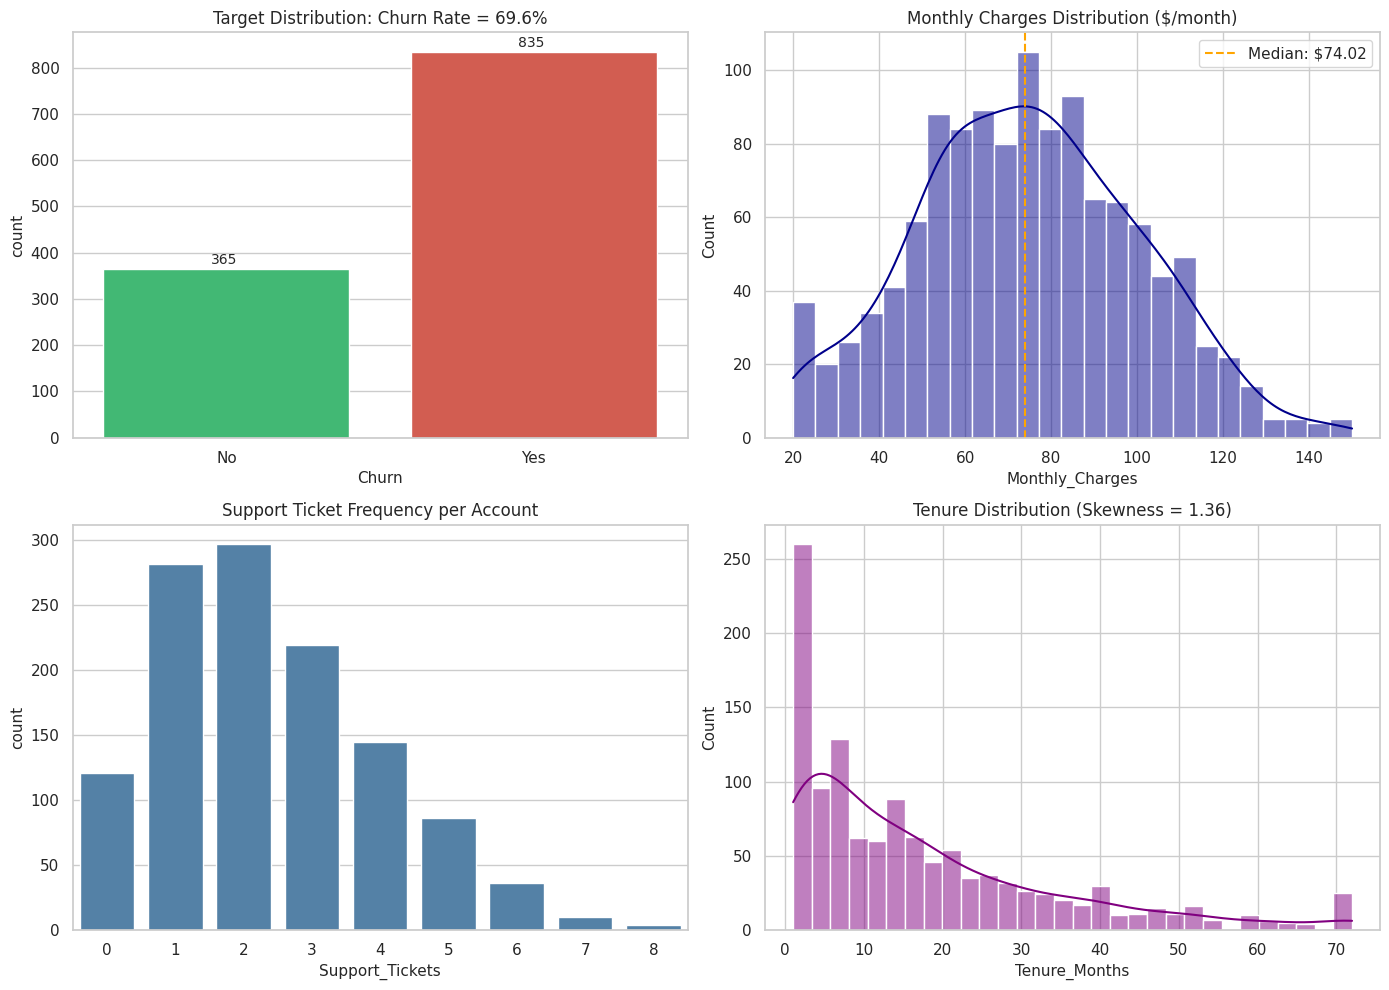

In [4]:
# ==============================================================================
# STAGE 3: UNIVARIATE ANALYSIS
# ==============================================================================
# The trainer investigates the target variable (Churn) and primary behavioral drivers.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Variable: Churn Distribution
churn_counts = df['Churn'].value_counts()
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])
axes[0, 0].set_title(f"Target Distribution: Churn Rate = {(churn_counts['Yes']/len(df))*100:.1f}%")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 10))

# 2. Continuous Numeric: Monthly Charges (KDE + Histogram)
sns.histplot(data=df, x='Monthly_Charges', kde=True, ax=axes[0, 1], color="darkblue", bins=25)
axes[0, 1].axvline(df['Monthly_Charges'].median(), color='orange', linestyle='--', label=f"Median: ${df['Monthly_Charges'].median():.2f}")
axes[0, 1].set_title("Monthly Charges Distribution ($/month)")
axes[0, 1].legend()

# 3. Discrete Numeric: Support Ticket Volume
sns.countplot(data=df, x='Support_Tickets', ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Support Ticket Frequency per Account")

# 4. Continuous Skewed: Tenure (Months)
sns.histplot(data=df, x='Tenure_Months', kde=True, ax=axes[1, 1], color="purple", bins=30)
axes[1, 1].set_title(f"Tenure Distribution (Skewness = {df['Tenure_Months'].skew():.2f})")

plt.tight_layout()
plt.show()

# --- Trainer Commentary ---
# "Our baseline churn rate is ~32%. Notice that Tenure is heavily right-skewed:
# most accounts are early in their lifecycle (0-15 months). Support tickets follow a Poisson-like
# distribution, but there is a distinct tail of accounts logging 4+ tickets."

/tmp/ipykernel_9909/1394585266.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


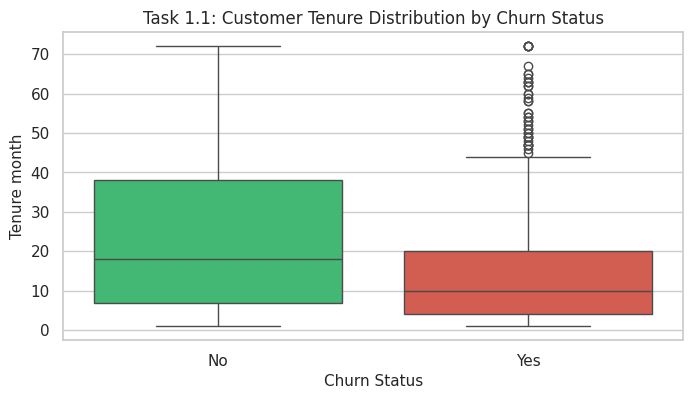

Median and IQR of Tenure by Churn Status:
       Median   Q1    Q3   IQR
Churn                         
No       18.0  7.0  38.0  31.0
Yes      10.0  4.0  20.0  16.0
--- Churn Rates across Contract & Tech Support ---


Churn                               No        Yes
Contract_Type  Tech_Support                      
Month-to-Month No            13.861386  86.138614
               No internet   15.178571  84.821429
               Yes           15.289256  84.710744
One-Year       No            31.884058  68.115942
               No internet   40.476190  59.523810
               Yes           48.120301  51.879699
Two-Year       No            63.551402  36.448598
               No internet   54.054054  45.945946
               Yes           65.116279  34.883721

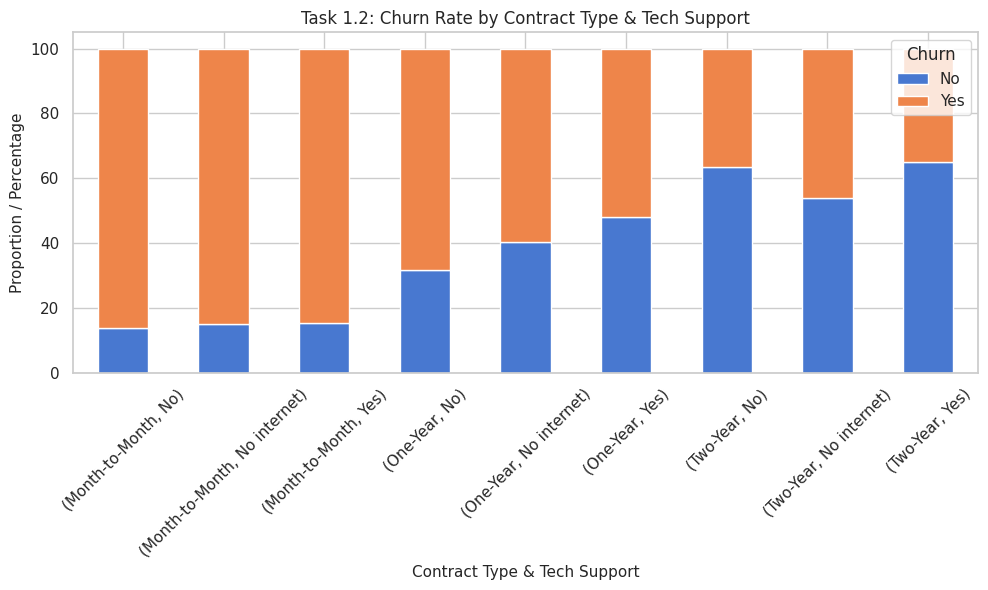

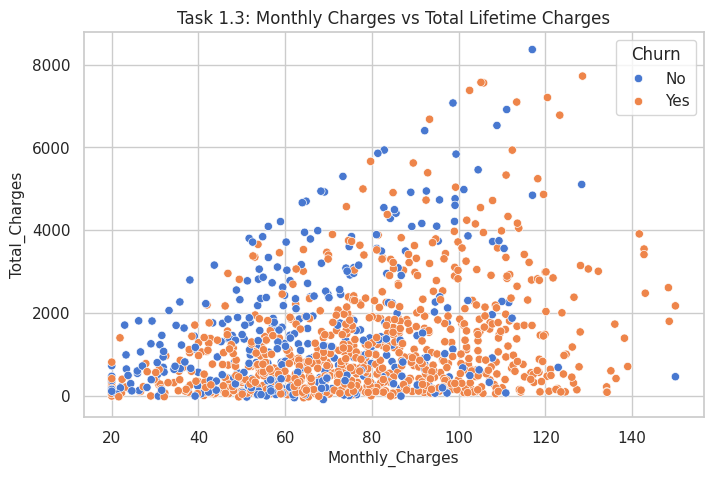

In [5]:
# ==============================================================================
# TASK 1: BIVARIATE ANALYSIS (3 Sub-Tasks)
# ==============================================================================

# ------------------------------------------------------------------------------
# 1.1 NUMERIC VS CATEGORICAL: Tenure vs. Churn
# Task: Create a grouped boxplot or violin plot of `Tenure_Months` grouped by `Churn`.
#       Compute and display the median and IQR of tenure for both groups.
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 4))

# TODO: Write your plotting code below (e.g., sns.boxplot or sns.violinplot)
sns.boxplot(
    data=df,
    x='Churn',
    y='Tenure_Months',
    palette=["#2ecc71", "#e74c3c"]
)

plt.title("Task 1.1: Customer Tenure Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure month")
plt.show()

# TODO: Compute and print the Median and IQR of Tenure for Churned vs Retained customers
tenure_stats = df.groupby('Churn')['Tenure_Months'].describe()[['50%', '25%', '75%']]

tenure_stats.columns = ['Median', 'Q1', 'Q3']
tenure_stats['IQR'] = tenure_stats['Q3'] - tenure_stats['Q1']

tenure_stats = tenure_stats.round(2)

print("Median and IQR of Tenure by Churn Status:")
print(tenure_stats)


# ------------------------------------------------------------------------------
# 1.2 CATEGORICAL VS CATEGORICAL: Tech Support & Contract Type vs. Churn
# Task: Generate a normalized crosstab (percentages) showing the churn rate across
#       different `Contract_Type` and `Tech_Support` combinations.
#       Plot as a stacked or grouped bar chart.
# ------------------------------------------------------------------------------
# TODO: Create the crosstab
contract_tech_churn = pd.crosstab(
    [df['Contract_Type'], df['Tech_Support']],
    df['Churn'],
    normalize='index'
) * 100
print("--- Churn Rates across Contract & Tech Support ---")
display(contract_tech_churn)

# TODO: Plot the crosstab as a bar chart
contract_tech_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Task 1.2: Churn Rate by Contract Type & Tech Support")
plt.ylabel("Proportion / Percentage")
plt.xlabel("Contract Type & Tech Support")
plt.xticks(rotation=45)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 1.3 NUMERIC VS NUMERIC: Monthly Charges vs. Total Charges
# Task: Generate a scatter plot comparing `Monthly_Charges` vs `Total_Charges`
#       colored by `Churn` status. Calculate the Pearson and Spearman correlations.
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))

# TODO: Write your scatterplot code below (sns.scatterplot with hue='Churn')
sns.scatterplot(
    data=df,
    x='Monthly_Charges',
    y='Total_Charges',
    hue='Churn'
)

plt.title("Task 1.3: Monthly Charges vs Total Lifetime Charges")
plt.show()

# TODO: Compute and print Pearson and Spearman correlation between Monthly_Charges and Total_Charges
pearson_corr = df['Monthly_Charges'].corr(
    df['Total_Charges'],
    method='pearson'
)
spearman_corr = df['Monthly_Charges'].corr(
    df['Total_Charges'],
    method='spearman'
)
# print(f"Pearson Correlation: {pearson_corr:.3f} | Spearman Correlation: {spearman_corr:.3f}")

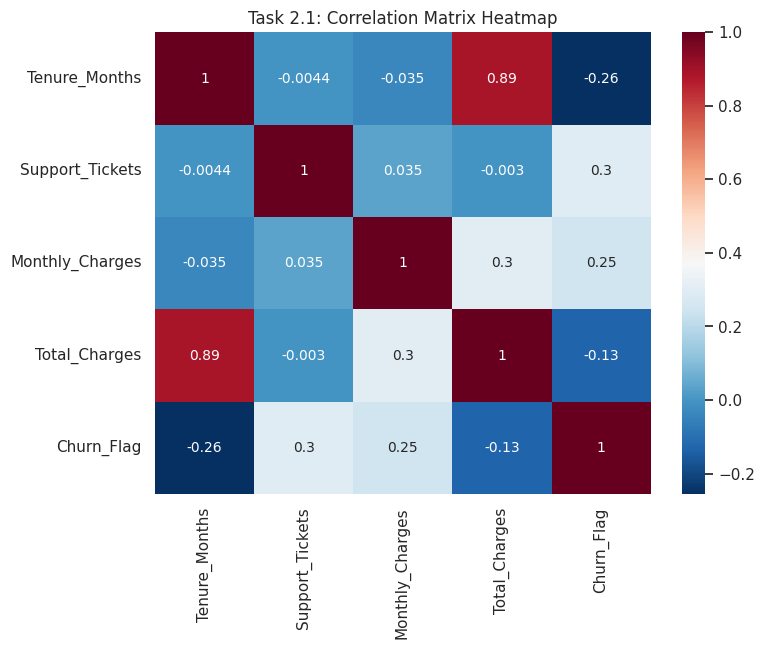

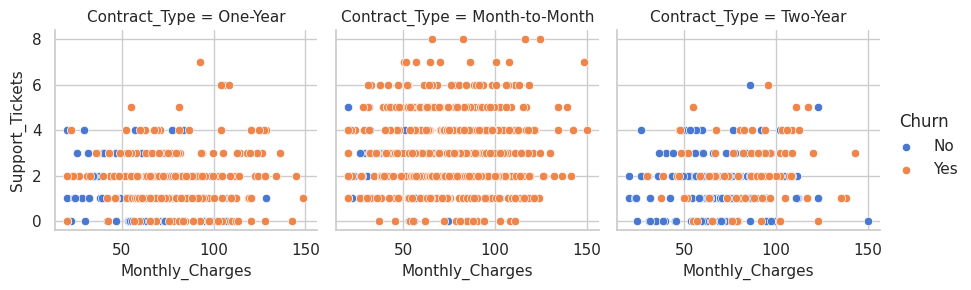

In [6]:
# ==============================================================================
# TASK 2: MULTIVARIATE ANALYSIS & ADVANCED SEGMENTATION
# ==============================================================================

# ------------------------------------------------------------------------------
# 2.1 CORRELATION HEATMAP
# Task: Encode 'Churn' as 1 (Yes) and 0 (No). Select all numeric columns and
#       plot an annotated correlation heatmap (sns.heatmap) using a divergent palette.
# ------------------------------------------------------------------------------
df_numeric = df.copy()

# TODO: Create binary numeric column 'Churn_Flag' (1 for 'Yes', 0 for 'No')
df_numeric['Churn_Flag'] = df_numeric['Churn'].map({'Yes': 1, 'No': 0})

# TODO: Calculate correlation matrix and display heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_numeric.corr(numeric_only=True),
    annot=True,
    cmap='RdBu_r'
)
plt.title("Task 2.1: Correlation Matrix Heatmap")
plt.show()


# ------------------------------------------------------------------------------
# 2.2 MULTI-DIMENSIONAL SEGMENTATION (FacetGrid / Subplots)
# Task: Plot `Monthly_Charges` vs `Support_Tickets` using FacetGrid segmented
#       by `Contract_Type` with `hue='Churn'`.
# ------------------------------------------------------------------------------
# TODO: Build and map a sns.FacetGrid
g = sns.FacetGrid(
    df,
    col='Contract_Type',
    hue='Churn'
)

g.map(
    sns.scatterplot,
    'Monthly_Charges',
    'Support_Tickets'
)

g.add_legend()

plt.show()

In [7]:
# ==============================================================================
# TASK 3: MISSING VALUE & OUTLIER TREATMENT (EDA CONTEXT)
# ==============================================================================

# ------------------------------------------------------------------------------
# 3.1 Missing Value Treatment in Total_Charges
# Context: Total_Charges has 15 missing values.
# Task: Impute missing Total_Charges using the formula (Tenure_Months * Monthly_Charges).
#       Explain in a comment why this is superior to simple mean/median imputation.
# ------------------------------------------------------------------------------

# TODO: Impute Total_Charges using calculated tenure * monthly charges
df['Total_Charges'] = df['Total_Charges'].fillna(
    df['Tenure_Months'] * df['Monthly_Charges'])

print(f"Missing values remaining in Total_Charges: {df['Total_Charges'].isna().sum()}")


# ------------------------------------------------------------------------------
# 3.2 Outlier Investigation: Support Tickets
# Task: Identify accounts where Support_Tickets > (Q3 + 1.5 * IQR).
#       Determine the churn rate among these high-ticket outliers.
# ------------------------------------------------------------------------------
# TODO: Calculate IQR fences for Support_Tickets
q1_tix = df['Support_Tickets'].quantile(0.25)
q3_tix = df['Support_Tickets'].quantile(0.75)
iqr_tix = q3_tix - q1_tix
upper_fence = q3_tix + 1.5 * iqr_tix

outlier_accounts = df[df['Support_Tickets'] > upper_fence]
print(f"Identified {len(outlier_accounts)} ticket-volume outliers.")
print(f"Churn Rate in Outlier Accounts: {(outlier_accounts['Churn'] == 'Yes').mean() * 100:.2f}%")

Missing values remaining in Total_Charges: 0
Identified 14 ticket-volume outliers.
Churn Rate in Outlier Accounts: 100.00%


In [8]:
# ==============================================================================
# TASK 4: HYPOTHESIS-DRIVEN FEATURE ENGINEERING
# ==============================================================================
# Task: Engineer at least TWO new features that capture behavioral or financial risk.
#
# Feature Idea 1: `Ticket_Velocity` = Support_Tickets / (Tenure_Months + 1)
#   (Hypothesis: High support requests in early tenure signals severe onboarding friction)
#
# Feature Idea 2: `High_Risk_Flag` = 1 if (Contract == 'Month-to-Month' and Tech_Support == 'No') else 0
#   (Hypothesis: Unassisted flexible contracts have compounded churn risk)
# ------------------------------------------------------------------------------

# TODO: Create Feature 1
df['Ticket_Velocity'] = df['Support_Tickets'] / (df['Tenure_Months'] + 1)

# TODO: Create Feature 2
df['High_Risk_Flag'] = (
    (df['Contract_Type'] == 'Month-to-Month') &
    (df['Tech_Support'] == 'No')
).astype(int)

# Validate predictive utility: Compare churn rates across your engineered features
print("--- Churn Rate Comparison for Engineered Features ---")
display(df.groupby('High_Risk_Flag')['Churn'].value_counts(normalize=True).unstack() * 100)
display(df.groupby('Churn')['Ticket_Velocity'].describe())

--- Churn Rate Comparison for Engineered Features ---


Churn,No,Yes
High_Risk_Flag,,
0,36.008919,63.991081
1,13.861386,86.138614


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,365.0,0.168059,0.276427,0.0,0.025000,0.065217,0.181818,2.0
Yes,835.0,0.415001,0.534765,0.0,0.090909,0.200000,0.500000,3.0


### 📊 Strategic Insight 1: [Short Descriptive Title]
* **Claim:** Customers with shorter tenure are substantially more likely to churn.
* **Evidence:** The median tenure for churned customers is 10 months, compared with 18 months for retained customers. The IQR is 4–20 months for churned customers versus 7–38 months for retained customers.
* **Business Action:** Strengthen onboarding and Customer Success engagement during the first 12 months, with proactive check-ins and early intervention for customers showing signs of dissatisfaction.

---

### 📊 Strategic Insight 2: [Short Descriptive Title]
* **Claim:** Month-to-month customers represent the highest-risk contract segment, regardless of technical support status.
* **Evidence:** Churn is approximately 84.7%–86.1% across the three Month-to-Month/Tech Support combinations. In comparison, Two-Year customers have churn rates of approximately 34.9%–46.0%.
* **Business Action:**Create targeted retention offers for Month-to-Month customers, such as annual-contract incentives, loyalty discounts, or contract upgrade campaigns.

---

### 📊 Strategic Insight 3: [Short Descriptive Title]
* **Claim:** Month-to-Month customers without technical support form a particularly high-risk customer segment.
* **Evidence:**The engineered High_Risk_Flag group has an 86.14% churn rate, compared with 63.99% for customers without the high-risk flag—a difference of approximately 22.15 percentage points.
* **Business Action:** Prioritize proactive technical support and Customer Success outreach for Month-to-Month customers who currently have no technical support.

---

### 📊 Strategic Insight 4: [Short Descriptive Title]
* **Claim:** Customers with unusually high support-ticket volumes are strongly associated with churn.
* **Evidence:** The upper outlier fence for Support_Tickets is 6 tickets (Q1 = 1, Q3 = 3, IQR = 2). There are 14 accounts above this threshold, and their churn rate is 100%.
* **Business Action:** Establish an escalation trigger for accounts exceeding 6 support tickets, followed by root-cause analysis, priority support, and direct Customer Success intervention.

---

### 📊 Strategic Insight 5: [Short Descriptive Title]
* **Claim:** Churned customers generate support requests at a higher rate relative to their tenure.
* **Evidence:** Median Ticket_Velocity is 0.20 for churned customers versus 0.065 for retained customers. The mean is 0.415 for churned customers compared with 0.168 for retained customers.
* **Business Action:** Use Ticket Velocity as an early-warning indicator and automatically flag customers with rapidly increasing support activity, particularly during early tenure.

In [9]:
# ==============================================================================
# TASK 7: GIT & GITHUB SUBMISSION INSTRUCTIONS (PORTFOLIO PUSH)
# ==============================================================================
"""
COMMAND-LINE / TERMINAL INSTRUCTIONS FOR PORTFOLIO SUBMISSION:

1. Download your completed notebook from Colab:
   File -> Download -> Download .ipynb

2. Move the file into your local portfolio Git repository:
   $ mv ~/Downloads/EDA_Customer_Churn_Portfolio.ipynb ~/projects/data-science-portfolio/

3. Commit and push to GitHub:
   $ cd ~/projects/data-science-portfolio/
   $ git add EDA_Customer_Churn_Portfolio.ipynb
   $ git commit -m "feat(eda): complete graded exploratory data analysis on SaaS customer churn"
   $ git push origin main

4. Ensure your GitHub README includes:
   - Executive Summary (Top 3 Findings)
   - Methodology & Visualizations
   - Recommended Strategic Interventions
"""

'\nCOMMAND-LINE / TERMINAL INSTRUCTIONS FOR PORTFOLIO SUBMISSION:\n\n1. Download your completed notebook from Colab:\n   File -> Download -> Download .ipynb\n\n2. Move the file into your local portfolio Git repository:\n   $ mv ~/Downloads/EDA_Customer_Churn_Portfolio.ipynb ~/projects/data-science-portfolio/\n\n3. Commit and push to GitHub:\n   $ cd ~/projects/data-science-portfolio/\n   $ git add EDA_Customer_Churn_Portfolio.ipynb\n   $ git commit -m "feat(eda): complete graded exploratory data analysis on SaaS customer churn"\n   $ git push origin main\n\n4. Ensure your GitHub README includes:\n   - Executive Summary (Top 3 Findings)\n   - Methodology & Visualizations\n   - Recommended Strategic Interventions\n'